# Apple Disease Detection
(Using Vit + LLM [ prompt engineering ])

Block Diagram of the Vision Transformer <br>
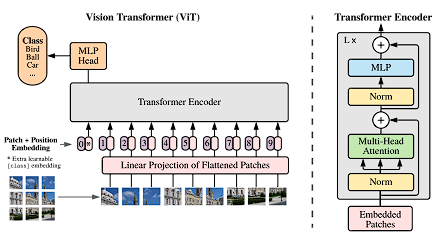

In [2]:
# Downloading dataset from drive
from google.colab import drive
drive.mount('/content/gdrive')

!cp -r '/content/gdrive/My Drive/apple_disease_dataset' /content/

Mounted at /content/gdrive


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Add, Dense, Dropout, Embedding, GlobalAveragePooling1D, Input, Layer, Softmax, LayerNormalization, MultiHeadAttention

In [4]:
IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32
RNG_SEED = 100
PATCH_DIM = 16
assert IMG_HEIGHT % PATCH_DIM == 0
assert IMG_WIDTH % PATCH_DIM == 0
PROJECTION_DIM = (PATCH_DIM ** 2) * 3

NUM_HEADS = 3 # per MSA block
NUM_BLOCKS = 6 # depth of transformer encoder

EPOCHS = 10

TRAINING_DATASET_DIR = '/content/apple_disease_dataset/train'
VALIDATION_DATASET_DIR = TRAINING_DATASET_DIR
TESTING_DATASET_DIR = '/content/apple_disease_dataset/test'

In [5]:
# Importing Images
train_ds = tf.keras.utils.image_dataset_from_directory(
  TRAINING_DATASET_DIR,
  validation_split=0.2,
  subset="training",
  seed=RNG_SEED,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  VALIDATION_DATASET_DIR,
  validation_split=0.2,
  subset="validation",
  seed=RNG_SEED,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
  TESTING_DATASET_DIR,
  image_size=(IMG_HEIGHT, IMG_WIDTH),
  batch_size=BATCH_SIZE
)

Found 4181 files belonging to 4 classes.
Using 3345 files for training.
Found 4181 files belonging to 4 classes.
Using 836 files for validation.
Found 474 files belonging to 4 classes.


Algorithm for extraction of patches from an image :-
1. Generate a kernel(mask) of Dimension PATCH_DIM X PATCH_DIM
2. Move the kernel on top of the image in a convolution like fashion with a stride length of (PATCH_DIM).
3. For every kernel position copy the RGB values of the image portion under the kernel in ROW MAJOR ORDER.
4. Doing this for every kernel position and storing the RGB values into a different buffer results in the patched image.
<br><br>
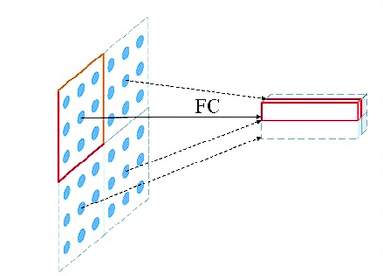

In [6]:
# Class for creating the patch embedding matrix
class PatchExtractor(Layer):
    def __init__(self):
        super(PatchExtractor, self).__init__()

    def call(self, images):
        batch_size = tf.shape(images)[0]
        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, PATCH_DIM, PATCH_DIM, 1],
            strides=[1, PATCH_DIM, PATCH_DIM, 1],
            rates=[1, 1, 1, 1],
            padding="VALID",
        )
        patch_dims = patches.shape[-1]
        patches = tf.reshape(patches, [batch_size, -1, patch_dims])
        return patches


Image tensor dimension : (128, 128, 3)
Label : Apple___Cedar_apple_rust


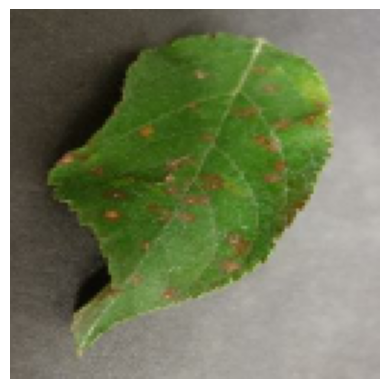




Patch Embedding tensor size : (1, 64, 768)


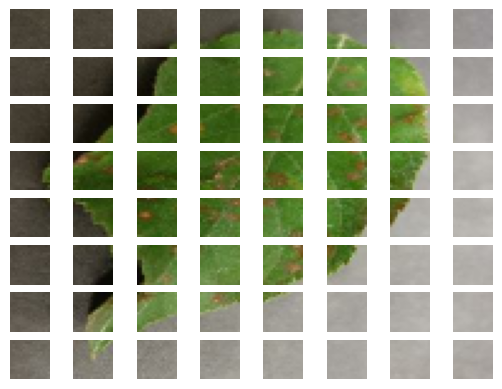



The patch tensor :-
tf.Tensor(
[[[ 76.    70.    58.   ...  72.75  66.75  54.75]
  [ 83.75  77.75  65.75 ...  67.5   61.5   49.5 ]
  [ 76.75  70.75  58.75 ...  69.    86.5   25.5 ]
  ...
  [164.25 161.25 156.25 ... 176.   173.   168.  ]
  [171.   168.   161.   ... 170.5  165.5  159.5 ]
  [176.5  173.5  168.5  ... 174.   169.   165.  ]]], shape=(1, 64, 768), dtype=float32)


In [7]:
# check for successful loading of images
demo_images, demo_labels = next(iter(train_ds))
demo_image, demo_label = demo_images[0], demo_labels[0]

print("Image tensor dimension : ", end="")
print(demo_image.shape)

# showing first image in batch
plt.imshow(demo_image.numpy().astype("uint8"))
plt.axis("off");
print("Label : ", end="")
print(train_ds.class_names[demo_label])
plt.show()

demo_img_patches = PatchExtractor()(tf.reshape(demo_image, shape=(1, *demo_image.shape)))
print(f"\n\n\nPatch Embedding tensor size : {demo_img_patches.shape}")
n = int(np.sqrt(demo_img_patches.shape[1]))
for i, patch in enumerate(demo_img_patches[0]):
  ax = plt.subplot(n, n, i + 1)
  patch_img = tf.reshape(patch, (PATCH_DIM, PATCH_DIM, 3))
  ax.imshow(patch_img.numpy().astype("uint8"))
  ax.axis("off")
plt.show()

print(f"\n\nThe patch tensor :-")
print(demo_img_patches)


In [8]:
# this class is responsible for adding positional encoding and also adding the class token to the patch embeddings
class PatchEncoder(Layer):
    def __init__(self, num_patches=(IMG_HEIGHT // PATCH_DIM) ** 2, projection_dim=PROJECTION_DIM):
        super(PatchEncoder, self).__init__()
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        w_init = tf.random_normal_initializer()
        class_token = w_init(shape=(1, projection_dim), dtype="float32")
        self.class_token = tf.Variable(initial_value=class_token, trainable=True)
        self.projection = Dense(units=projection_dim)
        self.position_embedding = Embedding(input_dim=num_patches+1, output_dim=projection_dim)

    def call(self, patch):
        batch = tf.shape(patch)[0]
        class_token = tf.tile(self.class_token, multiples = [batch, 1])
        class_token = tf.reshape(class_token, (batch, 1, self.projection_dim))
        # calculate patches embeddings
        patches_embed = self.projection(patch)
        patches_embed = tf.concat([patches_embed, class_token], 1)
        # calcualte positional embeddings
        positions = tf.range(start=0, limit=self.num_patches+1, delta=1)
        positions_embed = self.position_embedding(positions)
        # add both embeddings
        encoded = patches_embed + positions_embed
        return encoded

In [9]:
# testing PatchEncoder class
demo_encoded_patches = PatchEncoder()(demo_img_patches)
print(f"Encoded Patch Embedding tensor size : {demo_encoded_patches.shape}")

Encoded Patch Embedding tensor size : (1, 65, 768)


In [10]:
class MLP(Layer):
    def __init__(self, hidden_features, out_features, dropout_rate=0.1):
        super(MLP, self).__init__()
        self.dense1 = Dense(hidden_features, activation=tf.nn.gelu)
        self.dense2 = Dense(out_features)
        self.dropout = Dropout(dropout_rate)

    def call(self, x):
        x = self.dense1(x)
        x = self.dropout(x)
        x = self.dense2(x)
        y = self.dropout(x)
        return y

In [11]:
# Multiheaded self-attention, layer normalization and MLP forward in one layer
class Block(Layer):
    def __init__(self, projection_dim, num_heads=4, dropout_rate=0.1):
        super(Block, self).__init__()
        self.norm1 = LayerNormalization(epsilon=1e-6)
        # Create a multi-head attention layer.
        self.msa_block = MultiHeadAttention(num_heads=num_heads, key_dim=projection_dim, dropout=dropout_rate)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.mlp = MLP(projection_dim * 2, projection_dim, dropout_rate)

    def call(self, x):
        # Layer normalization 1.
        x1 = self.norm1(x) # encoded_patches
        attention_output = self.msa_block(x1, x1)
        x2 = Add()([attention_output, x])
        # Layer normalization 2.
        x3 = self.norm2(x2)
        # MLP.
        x3 = self.mlp(x3)
        y = Add()([x3, x2])
        return y

In [24]:
# this layer is a wrapper for the connection of multiple blocks (layer Block)
class TransformerEncoder(Layer):
    def __init__(self, projection_dim, num_heads=4, num_blocks=12, dropout_rate=0.1):
        super(TransformerEncoder, self).__init__()
        self.blocks = [Block(projection_dim, num_heads, dropout_rate) for _ in range(num_blocks)]
        self.norm = LayerNormalization(epsilon=1e-6)
        self.dropout = Dropout(0.5)

    def call(self, x):
        # Create a [batch_size, projection_dim] tensor.
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        y = self.dropout(x)
        return y

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ patch_extractor_4 (PatchExtractor)   │ (None, None, 768)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ patch_encoder_4 (PatchEncoder)       │ (None, 65, 768)             │         640,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ transformer_encoder_3                │ (None, 65, 768)             │     141,743,616 │
│ (TransformerEncoder)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d_3           │ (None, 768)                 │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mlp_51 (MLP)                         │ (None, 4)                   │         593,668 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax_49 (Softmax)                 │ (None, 4)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 142,977,796 (545.42 MB)

 Trainable params: 142,977,796 (545.42 MB)

 Non-trainable params: 0 (0.00 B)




Block Diagram of the VIT(MLP) model :-


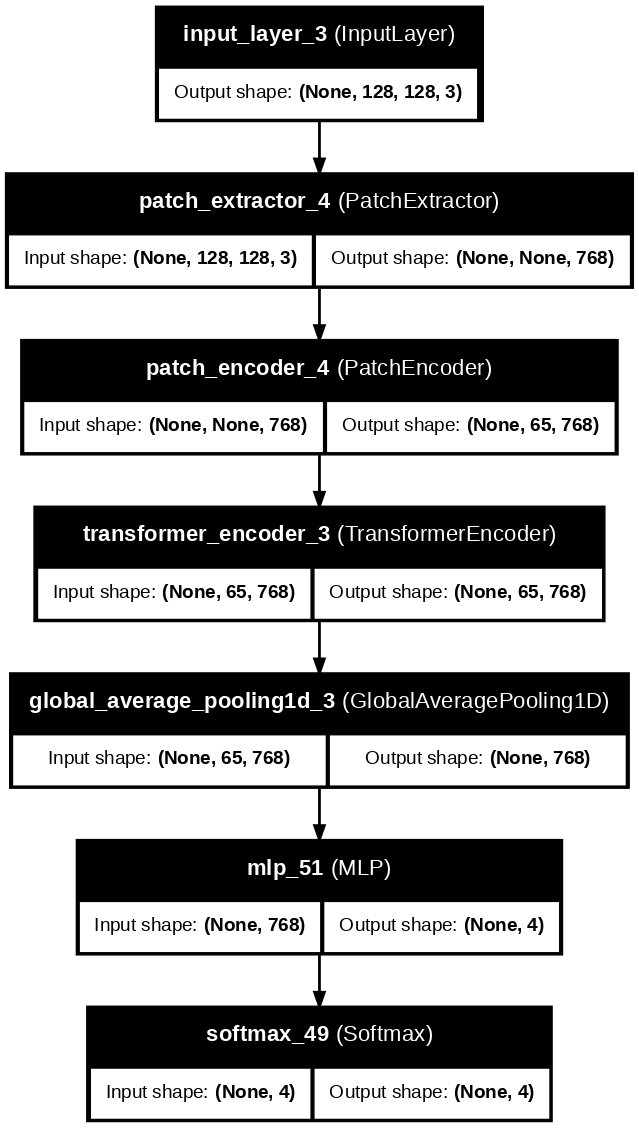

In [29]:
def construct_VIT_mlp(num_classes, num_heads=4, num_blocks=12, num_patches=(IMG_HEIGHT // PATCH_DIM) ** 2, projection_dim=PROJECTION_DIM, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)):
    inputs = Input(shape=input_shape)
    # Patch extractor
    patches = PatchExtractor()(inputs)
    # Patch encoder
    patches_embed = PatchEncoder(num_patches, projection_dim)(patches)
    # Transformer encoder
    representation = TransformerEncoder(projection_dim, num_heads, num_blocks)(patches_embed)
    representation = GlobalAveragePooling1D()(representation)
    # MLP to classify outputs
    final_output = MLP(projection_dim, num_classes, 0.5)(representation)
    final_output = Softmax()(final_output)
    # Create model
    model = Model(inputs=inputs, outputs=final_output)
    return model

vit_model_mlp = construct_VIT_mlp(len(train_ds.class_names))
vit_model_mlp.summary()

print("\n\n\nBlock Diagram of the VIT(MLP) model :-")

# model block diagram generator
tf.keras.utils.plot_model(
    vit_model_mlp,
#    to_file='/content/vit_model.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
#    rankdir='TB',
    expand_nested=True,
    dpi=100,
    show_layer_activations=True,
    show_trainable=False,
)

In [36]:
print(demo_labels)
def tensor_idx_to_onehot(label_tensor):
  values = label_tensor.numpy()
  n_values = np.max(values) + 1
  return tf.convert_to_tensor(np.eye(n_values)[values])

print(tensor_idx_to_onehot(demo_labels))

tf.Tensor([2 1 1 3 3 3 1 3 1 3 3 3 0 0 3 3 1 0 1 2 3 0 3 0 3 1 3 0 3 3 1 2], shape=(32,), dtype=int32)
tf.Tensor(
[[0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]], shape=(32, 4), dtype=float64)


In [ ]:
# Training VIT(MLP) model

optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001)

loss_fn = tf.keras.losses.CategoricalCrossentropy()
train_acc_metric = tf.keras.metrics.CategoricalAccuracy()
val_acc_metric = tf.keras.metrics.CategoricalAccuracy()

device = "/GPU:0" if tf.config.list_physical_devices('GPU') else "/CPU:0"
print(f"Using {device}")
with tf.device(device):
  for epoch in range(EPOCHS):
      for step, (images, labels) in enumerate(train_ds):
          labels = tensor_idx_to_onehot(labels)
          with tf.GradientTape() as tape:
              logits = vit_model_mlp(images, training=True)
              loss_value = loss_fn(labels, logits)

          grads = tape.gradient(loss_value, vit_model_mlp.trainable_weights)
          optimizer.apply_gradients(zip(grads, vit_model_mlp.trainable_weights))

          train_acc_metric.update_state(labels, logits)

      # Validation
      for step, (images, labels) in enumerate(val_ds):
          labels = tensor_idx_to_onehot(labels)
          val_logits = vit_model_mlp(images, training=False)
          val_acc_metric.update_state(labels, val_logits)

      train_acc = train_acc_metric.result()
      val_acc = val_acc_metric.result()
      print(f"Epoch {epoch + 1} : ", end="")
      print(f"Training accuracy: {train_acc:.4f}  Validation accuracy: {val_acc:.4f}")
      val_acc_metric.reset_state()
      train_acc_metric.reset_state()

Using /GPU:0
Epoch 1 : Training accuracy: 0.2912  Validation accuracy: 0.3493
Epoch 2 : Training accuracy: 0.2670  Validation accuracy: 0.3493
Epoch 3 : Training accuracy: 0.2936  Validation accuracy: 0.5443
Epoch 4 : Training accuracy: 0.3408  Validation accuracy: 0.4199
Epoch 5 : Training accuracy: 0.3513  Validation accuracy: 0.3529
Epoch 6 : Training accuracy: 0.3280  Validation accuracy: 0.3660
Epoch 7 : Training accuracy: 0.3372  Validation accuracy: 0.5586
Epoch 8 : Training accuracy: 0.3333  Validation accuracy: 0.5514
Epoch 9 : Training accuracy: 0.3250  Validation accuracy: 0.5299
Epoch 10 : Training accuracy: 0.3199  Validation accuracy: 0.3457
